# **Delay Patterns Study Notebook**

## Objectives

* Answer business requirement 1:
  * Use the collections dataset (outputs/datasets/collection/airlineDelayPredictor.csv) to explore patterns of flight delays across airlines and airports
  * Identify and visualize airlines, airports and month prone to high delays.

## Inputs

* outputs/datasets/collection/airlineDelayPredictor.csv

## Outputs

* Generate code that answers business requirement 1 and will be used as inoput when building the dashboard in Streamlit App.

---

# Set working directory

In [1]:
import os
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
current_dir = os.getcwd()
current_dir

'/workspaces/airline-delay-predictor'

In [2]:
# Disable warnings:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Load Data

In [7]:
from dask import dataframe as dd

dtype_map = {
    'CANCELLATION_REASON': 'object',
}

df = dd.read_csv('outputs/datasets/collection/usDOTflightDelay_*.csv', dtype=dtype_map).compute()
df.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,date,flight_depart_delayed,flight_arrive_delayed,Delay_Total,flight_total_delay,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct
0,2015,1,17,6,WN,2852,N7733B,BWI,DAY,2035,...,2015-01-17,0,0,0.0,0,0.00,0.0,0.00,0.0,0.0
1,2015,1,26,1,B6,821,N579JB,BOS,PBI,1342,...,2015-01-26,1,1,74.0,1,14.86,0.0,85.14,0.0,0.0
2,2015,1,3,6,EV,5082,N131EV,ATL,BMI,1025,...,2015-01-03,0,0,0.0,0,0.00,0.0,0.00,0.0,0.0
3,2015,1,26,1,WN,2410,N235WN,BWI,FLL,1425,...,2015-01-26,0,0,0.0,0,0.00,0.0,0.00,0.0,0.0
4,2015,1,12,1,US,2054,N717UW,JAX,CLT,1035,...,2015-01-12,0,0,0.0,0,0.00,0.0,0.00,0.0,0.0


---

# Data Exploration

Check variable types and distribution, missing values.

In [8]:
from ydata_profiling import ProfileReport
pandas_report = ProfileReport(df=df, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Column data types and missing values

In [9]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 0 to 4418
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   YEAR                     40000 non-null  int64  
 1   MONTH                    40000 non-null  int64  
 2   DAY                      40000 non-null  int64  
 3   DAY_OF_WEEK              40000 non-null  int64  
 4   AIRLINE                  40000 non-null  string 
 5   FLIGHT_NUMBER            40000 non-null  int64  
 6   TAIL_NUMBER              40000 non-null  string 
 7   ORIGIN_AIRPORT           40000 non-null  string 
 8   DESTINATION_AIRPORT      40000 non-null  string 
 9   SCHEDULED_DEPARTURE      40000 non-null  int64  
 10  DEPARTURE_TIME           40000 non-null  float64
 11  DEPARTURE_DELAY          40000 non-null  float64
 12  TAXI_OUT                 40000 non-null  float64
 13  WHEELS_OFF               40000 non-null  float64
 14  SCHEDULED_TIME           400

YEAR                           0
MONTH                          0
DAY                            0
DAY_OF_WEEK                    0
AIRLINE                        0
FLIGHT_NUMBER                  0
TAIL_NUMBER                    0
ORIGIN_AIRPORT                 0
DESTINATION_AIRPORT            0
SCHEDULED_DEPARTURE            0
DEPARTURE_TIME                 0
DEPARTURE_DELAY                0
TAXI_OUT                       0
WHEELS_OFF                     0
SCHEDULED_TIME                 0
ELAPSED_TIME                  93
AIR_TIME                      93
DISTANCE                       0
WHEELS_ON                     19
TAXI_IN                       19
SCHEDULED_ARRIVAL              0
ARRIVAL_TIME                  19
ARRIVAL_DELAY                  0
DIVERTED                       0
CANCELLED                      0
CANCELLATION_REASON        40000
AIR_SYSTEM_DELAY               0
SECURITY_DELAY                 0
AIRLINE_DELAY                  0
LATE_AIRCRAFT_DELAY            0
WEATHER_DE

### Descriptive stats

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,40000.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,40000.0,6.548925,3.396394,1.0,4.0,7.0,9.0,12.0
DAY,40000.0,15.691725,8.768210,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,40000.0,3.926250,1.993768,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,40000.0,2163.877875,1756.614164,1.0,727.0,1672.0,3215.0,7432.0
SCHEDULED_DEPARTURE,40000.0,1329.926875,483.696792,5.0,920.0,1325.0,1732.0,2359.0
DEPARTURE_TIME,40000.0,1336.632975,496.843041,1.0,922.0,1332.0,1742.0,2359.0
DEPARTURE_DELAY,40000.0,9.753100,38.948581,-39.0,-5.0,-2.0,7.0,1551.0
TAXI_OUT,40000.0,15.987250,8.814649,1.0,11.0,14.0,19.0,177.0
WHEELS_OFF,40000.0,1358.861225,498.143349,2.0,936.0,1345.0,1757.0,2400.0


# Timeseries of delays

### Monthly Delays

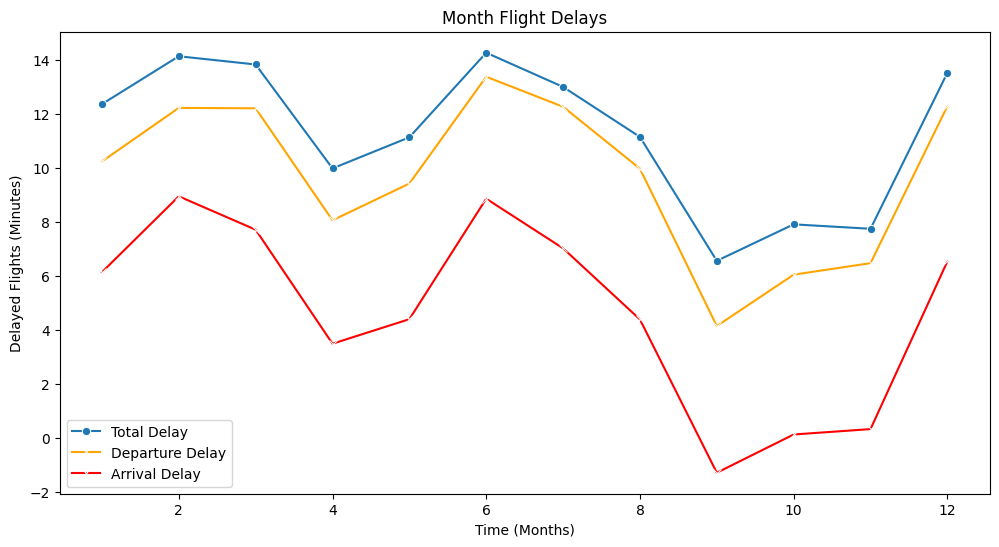

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

%matplotlib inline

mean_data = df.groupby("MONTH")[["Delay_Total",'ARRIVAL_DELAY','DEPARTURE_DELAY']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=mean_data, x="MONTH", y="Delay_Total", marker="o", ax=ax1, label="Total Delay")
sns.lineplot(data=mean_data, x="MONTH", y="DEPARTURE_DELAY", color="orange", marker="x", ax=ax1, label="Departure Delay")
sns.lineplot(data=mean_data, x="MONTH", y="ARRIVAL_DELAY", color="red", marker="x", ax=ax1, label="Arrival Delay")
# ax1.set_xticks(range(len(df)), labels=range(2011, 2019))

ax1.set_title("Month Flight Delays")
ax1.set_xlabel("Time (Months)")
ax1.set_ylabel("Delayed Flights (Minutes)")
plt.show()

### Delay by airline

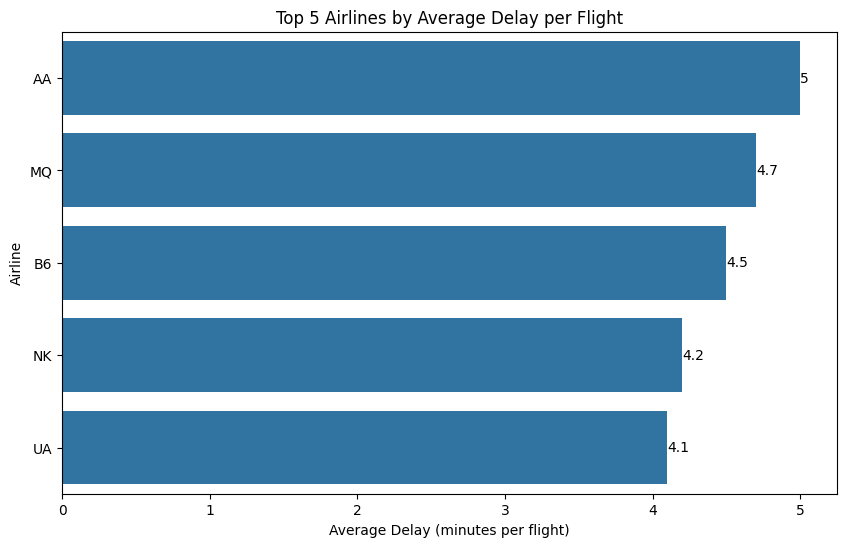

In [13]:
airline_delay = df.groupby("AIRLINE")[["AIRLINE_DELAY"]].mean().sort_values("AIRLINE_DELAY", ascending=False).head(5)
airline_delay = airline_delay.round({'AIRLINE_DELAY': 1})

plt.figure(figsize=(10, 6))
ax=sns.barplot(x="AIRLINE_DELAY", y=airline_delay.index, data=airline_delay)
# monthly_trend = df.groupby("MONTH")[["AIRLINE_DELAY",'ARRIVAL_DELAY','DEPARTURE_DELAY']].mean().reset_index()
ax.bar_label(ax.containers[0])
plt.title("Top 5 Airlines by Average Delay per Flight")
plt.xlabel("Average Delay (minutes per flight)")
plt.ylabel("Airline")
plt.show()

### Delay by Airport

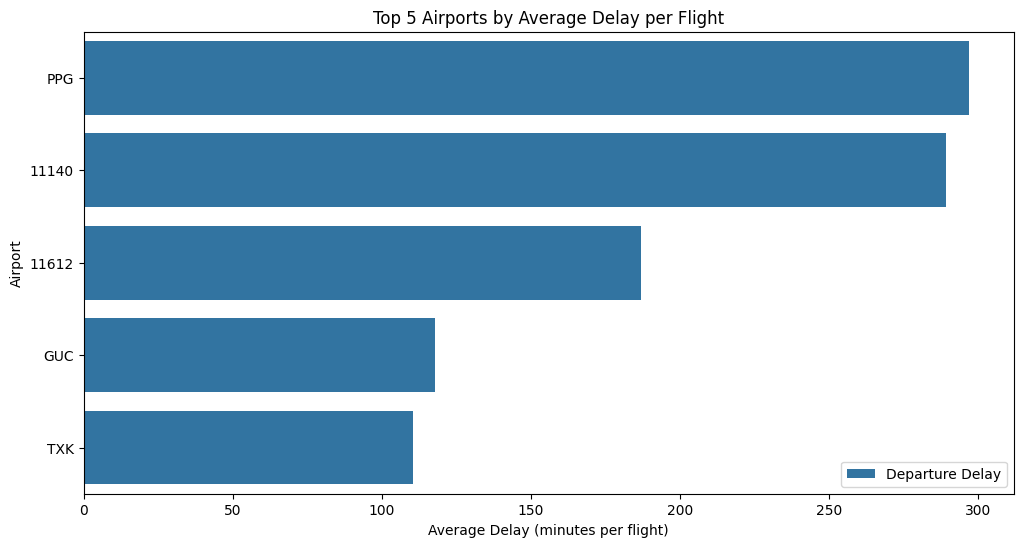

In [14]:
airport_origin = df.groupby("ORIGIN_AIRPORT")[["DEPARTURE_DELAY"]].mean().sort_values("DEPARTURE_DELAY", ascending=False).head(5)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x="DEPARTURE_DELAY", y=airport_origin.index, data=airport_origin, ax=ax1, label="Departure Delay")
plt.title("Top 5 Airports by Average Delay per Flight")
plt.xlabel("Average Delay (minutes per flight)")
plt.ylabel("Airport")
plt.show()

### Delay Composition

In [19]:
# delay comp 
delay_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
avg_cause_pct = df[[f"{c}_pct" for c in delay_cols]].mean().sort_values(ascending=False)


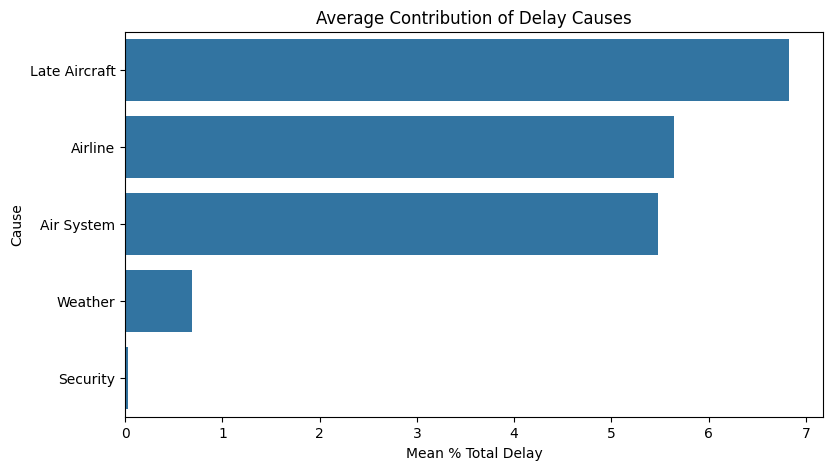

In [20]:
labels =[x.replace('_DELAY_pct', '').replace('_', ' ').title() for x in avg_cause_pct.index]

plt.figure(figsize=(9, 5))
sns.barplot(x=avg_cause_pct.values, y=labels)
plt.title("Average Contribution of Delay Causes")
plt.xlabel("Mean % Total Delay")
plt.ylabel("Cause")
plt.show()

# Correlation Study

### Correlation and PPS

In [21]:
import ppscore as pps
import numpy as np

def heatmap_corr(df,threshold, figsize=(20,12), font_annot = 8):
  if len(df.columns) > 1:
    mask = np.zeros_like(df, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    mask[abs(df) < threshold] = True

    fig, axes = plt.subplots(figsize=figsize)
    sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                mask=mask, cmap='viridis', annot_kws={"size": font_annot}, ax=axes,
                linewidth=0.5
                     )
    
    # if gridlines:
    axes.axhline(y=0, color='k',linewidth=10)
    axes.axhline(y=df.shape[1], color='k',linewidth=10)
    axes.axvline(x=0, color='k',linewidth=10)
    axes.axvline(x=df.shape[0], color='k',linewidth=10)
  
    axes.set_yticklabels(df.columns, rotation = 0)
    plt.ylim(len(df.columns),0)
    plt.show()


def heatmap_pps(df,threshold, figsize=(20,12), font_annot = 8):
    if len(df.columns) > 1:

      mask = np.zeros_like(df, dtype=bool)
      mask[abs(df) < threshold] = True

      fig, ax = plt.subplots(figsize=figsize)
      ax = sns.heatmap(df, annot=True, xticklabels=True,yticklabels=True,
                       mask=mask,cmap='rocket_r', annot_kws={"size": font_annot},
                       linewidth=0.05,linecolor='grey')
      
      # if gridlines:
      ax.axhline(y=0, color='k',linewidth=10)
      ax.axhline(y=df.shape[1], color='k',linewidth=10)
      ax.axvline(x=0, color='k',linewidth=10)
      ax.axvline(x=df.shape[0], color='k',linewidth=10)
      
      plt.ylim(len(df.columns),0)
      plt.show()


def CalculateCorrAndPPS(df):
  df_corr_spearman = df.corr(method="spearman")
  df_corr_pearson = df.corr(method="pearson")

  pps_matrix_raw = pps.matrix(df)
  pps_matrix = pps_matrix_raw.filter(['x', 'y', 'ppscore']).pivot(columns='x', index='y', values='ppscore')

  pps_score_stats = pps_matrix_raw.query("ppscore < 1").filter(['ppscore']).describe().T
  print("--- PPS threshold - PPS score IQR --- \n")
  print(pps_score_stats.round(3))

  return df_corr_pearson, df_corr_spearman, pps_matrix


def DisplayCorrAndPPS(df_corr_pearson, df_corr_spearman, pps_matrix,CorrThreshold,PPS_Threshold,
                      figsize=(20,12), font_annot=8 ):

  print("\n")
  print("*** Heatmap: Spearman Correlation ***")
  heatmap_corr(df=df_corr_spearman, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

  print("\n")
  print("*** Heatmap: Pearson Correlation ***")
  heatmap_corr(df=df_corr_pearson, threshold=CorrThreshold, figsize=figsize, font_annot=font_annot)

  print("\n")
  print("*** Heatmap: Predictive power Score (PPS) ***")
  heatmap_pps(df=pps_matrix,threshold=PPS_Threshold, figsize=figsize, font_annot=font_annot)

In [22]:
corr_cols = delay_cols + ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY','SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY','flight_depart_delayed',
       'flight_arrive_delayed', 'Delay_Total', 'flight_total_delay',]
df_corr_pearson, df_corr_spearman, pps_matrix = CalculateCorrAndPPS(df[corr_cols])

--- PPS threshold - PPS score IQR --- 

         count   mean    std  min  25%  50%  75%    max
ppscore  545.0  0.053  0.176  0.0  0.0  0.0  0.0  0.993


In [23]:
corr_pearson_results =df_corr_pearson['flight_depart_delayed'].sort_values(key=abs, ascending=False)[1:]
corr_spearman_results =df_corr_spearman['flight_depart_delayed'].sort_values(key=abs, ascending=False)[1:]
corr_pearson_results

flight_arrive_delayed    0.749778
flight_total_delay       0.749778
DEPARTURE_DELAY          0.639031
ARRIVAL_DELAY            0.606082
Delay_Total              0.562477
LATE_AIRCRAFT_DELAY      0.450813
AIRLINE_DELAY            0.305039
AIR_SYSTEM_DELAY         0.219322
DEPARTURE_TIME           0.215450
SCHEDULED_DEPARTURE      0.163839
WEATHER_DELAY            0.149055
SCHEDULED_ARRIVAL        0.142563
ARRIVAL_TIME             0.112926
MONTH                   -0.038122
SECURITY_DELAY           0.033061
ELAPSED_TIME             0.027360
SCHEDULED_TIME           0.024537
DISTANCE                 0.021912
AIR_TIME                 0.021439
DAY_OF_WEEK             -0.015839
DAY                     -0.010264
TAXI_IN                 -0.009489
YEAR                          NaN
Name: flight_depart_delayed, dtype: float64

Create heatmap plot



*** Heatmap: Spearman Correlation ***


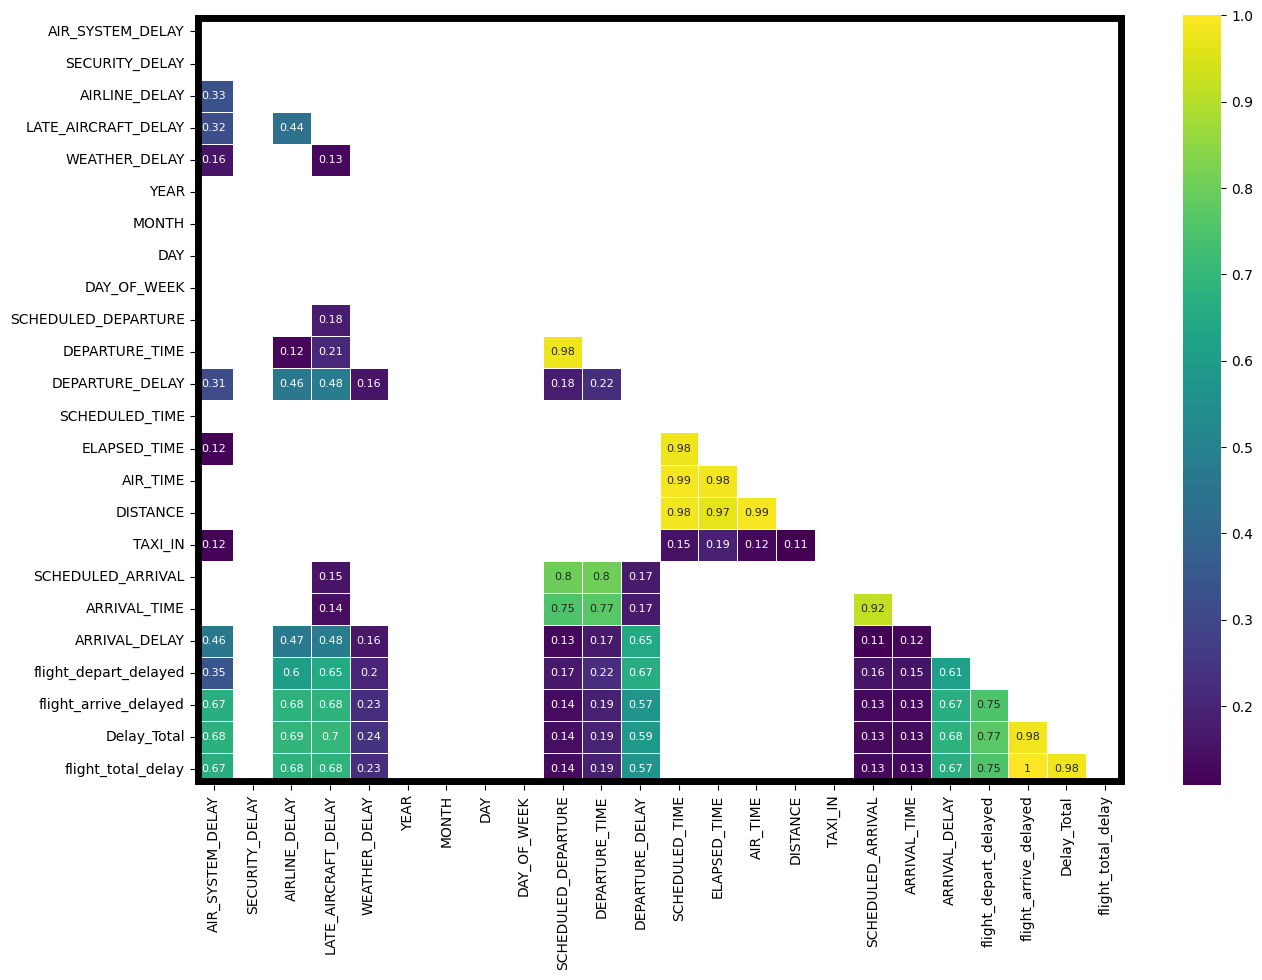



*** Heatmap: Pearson Correlation ***


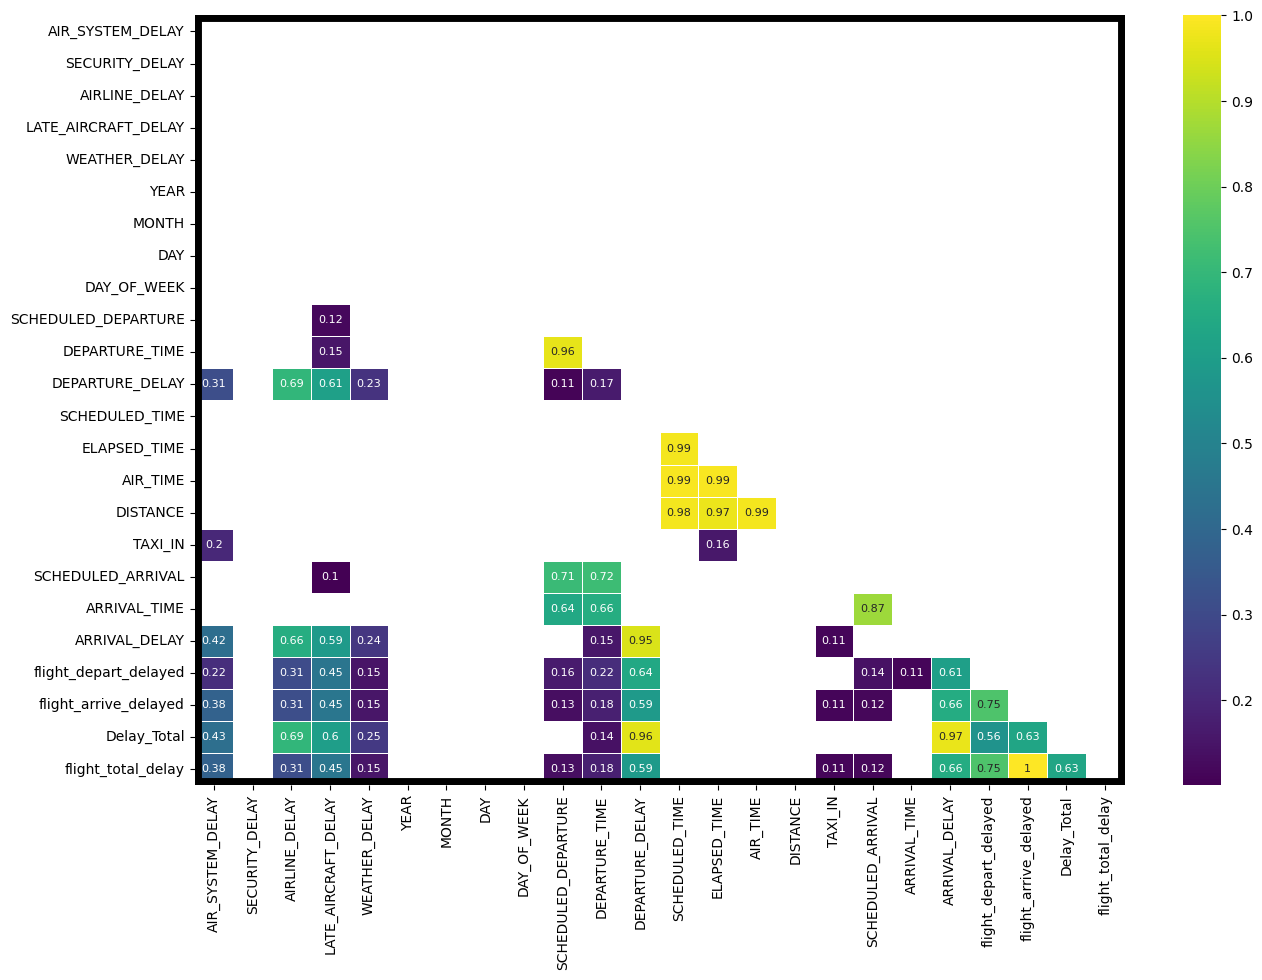



*** Heatmap: Predictive power Score (PPS) ***


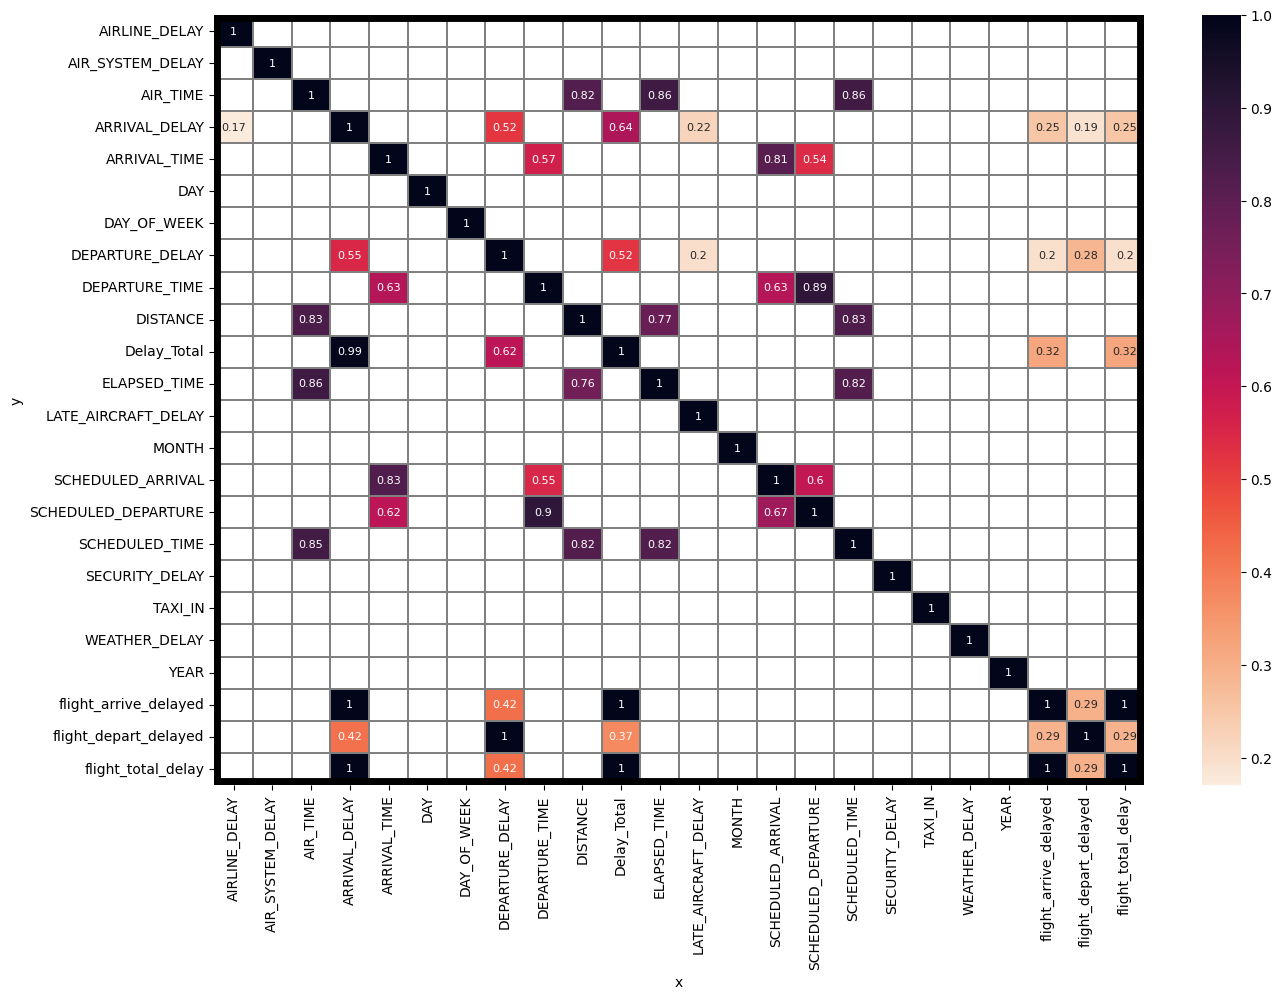

In [24]:
DisplayCorrAndPPS(df_corr_pearson=df_corr_pearson,
                  df_corr_spearman=df_corr_spearman, 
                  pps_matrix=pps_matrix,
                  CorrThreshold=0.1, PPS_Threshold=0.15,
                  figsize=(15,10), font_annot=8)

### Variables to study

In [25]:
# Top variables to study
top_n = 15
vars_to_study = list(set(corr_pearson_results[:top_n].index.to_list() + corr_spearman_results[:top_n].index.to_list()))
vars_to_study 

['AIR_SYSTEM_DELAY',
 'flight_total_delay',
 'AIRLINE_DELAY',
 'SCHEDULED_DEPARTURE',
 'SECURITY_DELAY',
 'WEATHER_DELAY',
 'Delay_Total',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DEPARTURE_DELAY',
 'MONTH',
 'SCHEDULED_ARRIVAL',
 'LATE_AIRCRAFT_DELAY',
 'DEPARTURE_TIME',
 'flight_arrive_delayed']

## EDA on selected variables

In [26]:
df_eda = df.filter(vars_to_study + ['flight_depart_delayed'])
df_eda['AIR_SYSTEM_DELAY'] = df_eda['AIR_SYSTEM_DELAY'].fillna(0)
df_eda.head(3)


,AIR_SYSTEM_DELAY,flight_total_delay,AIRLINE_DELAY,SCHEDULED_DEPARTURE,SECURITY_DELAY,WEATHER_DELAY,Delay_Total,ARRIVAL_TIME,ARRIVAL_DELAY,DEPARTURE_DELAY,MONTH,SCHEDULED_ARRIVAL,LATE_AIRCRAFT_DELAY,DEPARTURE_TIME,flight_arrive_delayed,flight_depart_delayed
0,0.0,0,0.0,2035,0.0,0.0,0.0,2200.0,-5.0,6.0,1,2205,0.0,2041.0,0,0
1,11.0,1,63.0,1342,0.0,0.0,74.0,1820.0,74.0,63.0,1,1706,0.0,1445.0,1,1
2,0.0,0,0.0,1025,0.0,0.0,0.0,1111.0,0.0,4.0,1,1111,0.0,1029.0,0,0


### Distribution findings - summary

In [27]:
# Delay by month
delay_month = df.groupby('MONTH')['flight_depart_delayed'].mean().sort_values(ascending=False).round(3)*100
delay_month
# Most delays in summer Jun,Jul and some winter months Dec,Feb

MONTH
6     21.9
2     21.7
7     21.0
12    20.6
3     20.1
1     19.1
8     18.2
4     16.9
5     16.8
11    14.4
10    12.5
9     11.6
Name: flight_depart_delayed, dtype: float64

In [28]:
# Delay by depart time
df['hour'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)
bins = [-1, 5, 11, 17,21, 24]
labels = ['Late Night (0-5am)', 'Morning (6-11am)', 'Afternoon (12pm-5pm)', 'Evening (6pm-9pm)', 'Night (10pm-11pm)']
df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels)

df['time_of_day'] 
delay_time = df.groupby('time_of_day')['flight_depart_delayed'].mean().sort_values(ascending=False).round(3)*100
delay_time
# Most delays occurs between 6pm and 11pm

time_of_day
Evening (6pm-9pm)       26.4
Night (10pm-11pm)       21.7
Afternoon (12pm-5pm)    20.9
Morning (6-11am)        11.2
Late Night (0-5am)       7.2
Name: flight_depart_delayed, dtype: float64

In [29]:
# Delay by ORIGIN_AIRPORT
delay_airport = df.groupby('AIRLINE')['flight_depart_delayed'].mean().sort_values(ascending=False).round(3)*100
delay_airport
# Most delays from Spirit (23.8%) and United (22.4%) airlines

AIRLINE
NK    23.5
B6    22.7
UA    22.2
F9    21.9
WN    21.0
MQ    19.2
EV    17.6
VX    17.3
AA    17.3
OO    16.0
US    13.6
DL    13.5
AS    10.3
HA     6.0
Name: flight_depart_delayed, dtype: float64

In [30]:
# Delay by source - mean durations
df[df['flight_depart_delayed']==1][delay_cols].mean().sort_values(ascending=False)


LATE_AIRCRAFT_DELAY    24.401842
AIRLINE_DELAY          20.110088
AIR_SYSTEM_DELAY        9.229245
WEATHER_DELAY           3.176364
SECURITY_DELAY          0.058881
dtype: float64

In [31]:
# Delay by source - percentage
df['main_delay'] = df[delay_cols].idxmax(axis=1)
df['main_delay'].value_counts(normalize=True).sort_values(ascending=False).round(4)*100



main_delay
AIR_SYSTEM_DELAY       86.52
LATE_AIRCRAFT_DELAY     7.29
AIRLINE_DELAY           5.48
WEATHER_DELAY           0.70
SECURITY_DELAY          0.02
Name: proportion, dtype: float64

---

# Conclusions and Next Steps

Flight Delay patterns can be summarised as follows:

* **% delays by month:** most delayed flights occurred in June and February (both ~22%) followed by July (21%) and December (~21%), while least delays occurred in September (<12%) and October (<13%).

* **% delay by time of day (departures):** Delays were most common for evening departures (+26%), followed by night (~22%) and afternoon flights (~21%), while morning (+11%) and late-night (+7%) departures experienced far fewer delays

* **% delay by airline:** Average delay varied widely across airlines with Spirit (~24%), JetBlue (~23%), and United (~22%) airlines with the most flights delayed, while Hawaiian (6%) and Alaska (~10%) had fewer flights delayed.

* **Average delay duration by cause:** delays caused by late-arriving aircraft (~24 minutes) and airline-related issues (~20 minutes).

* **Delay contributors:** Most flight delays were driven by air system issues (86.5%), followed by late arriving aircraft (7.3%), while airline-related causes (5.5%), weather (0.7%) and security (0.02%) contributed minimally